In [7]:
from pathlib import Path

dataset_path = Path("../../data/item_images/raw/bangladesh_ewaste")

for item in dataset_path.iterdir():
    print(item.name)

data.yaml
README.dataset.txt
README.roboflow.txt
test
train
valid


In [8]:
for path in dataset_path.rglob("*"):
    if path.is_dir():
        print(path)

..\..\data\item_images\raw\bangladesh_ewaste\test
..\..\data\item_images\raw\bangladesh_ewaste\train
..\..\data\item_images\raw\bangladesh_ewaste\valid
..\..\data\item_images\raw\bangladesh_ewaste\test\images
..\..\data\item_images\raw\bangladesh_ewaste\test\labels
..\..\data\item_images\raw\bangladesh_ewaste\train\images
..\..\data\item_images\raw\bangladesh_ewaste\train\labels
..\..\data\item_images\raw\bangladesh_ewaste\valid\images
..\..\data\item_images\raw\bangladesh_ewaste\valid\labels


In [9]:
yaml_path = dataset_path / "data.yaml"

with open(yaml_path, "r") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 12
names: ['Battery_Waste', 'Glass_Waste', 'Keyboard', 'Light_Bulb', 'Medical_Waste', 'Metal_Waste', 'Mobile', 'Mouse', 'Organic_Waste', 'PCB', 'Paper_Waste', 'Plastic_Waste']

roboflow:
  workspace: azizul-abedin-azmi-uwbiw
  project: e-waste-uvzkj
  version: 5
  license: CC BY 4.0
  url: https://universe.roboflow.com/azizul-abedin-azmi-uwbiw/e-waste-uvzkj/dataset/5


Count Mobile and PCB images

In [10]:
from pathlib import Path

target_classes = {
    6: "mobile_phone",
    9: "pcb"
}

image_counts = {
    "mobile_phone": 0,
    "pcb": 0
}

object_counts = {
    "mobile_phone": 0,
    "pcb": 0
}

split_counts = {}

for split in ["train", "valid", "test"]:

    label_folder = dataset_path / split / "labels"

    split_counts[split] = {
        "mobile_phone": 0,
        "pcb": 0
    }

    for label_file in label_folder.glob("*.txt"):

        classes_in_image = set()

        with open(label_file, "r") as f:

            for line in f:

                parts = line.strip().split()

                if not parts:
                    continue

                class_id = int(parts[0])

                if class_id in target_classes:

                    class_name = target_classes[class_id]

                    object_counts[class_name] += 1
                    classes_in_image.add(class_name)

        for class_name in classes_in_image:

            image_counts[class_name] += 1
            split_counts[split][class_name] += 1


print("Images containing each class:")
print(image_counts)

print("\nTotal objects:")
print(object_counts)

print("\nSplit-wise:")
print(split_counts)

Images containing each class:
{'mobile_phone': 151, 'pcb': 205}

Total objects:
{'mobile_phone': 151, 'pcb': 205}

Split-wise:
{'train': {'mobile_phone': 99, 'pcb': 144}, 'valid': {'mobile_phone': 26, 'pcb': 30}, 'test': {'mobile_phone': 26, 'pcb': 31}}


Check whether Mobile and PCB appear together with other objects

In [37]:
mixed_images = []

for split in ["train", "valid", "test"]:

    label_folder = dataset_path / split / "labels"

    for label_file in label_folder.glob("*.txt"):

        class_ids = []

        with open(label_file, "r") as f:

            for line in f:

                parts = line.strip().split()

                if parts:
                    class_ids.append(int(parts[0]))

        if 6 in class_ids or 9 in class_ids:

            if len(class_ids) > 1:

                mixed_images.append(
                    (split, label_file.name, class_ids)
                )

print("zero images with multiple annotation rows:", len(mixed_images))

print("\nFirst 10 examples:")
for item in mixed_images[:10]:
    print(item)

zero images with multiple annotation rows: 0

First 10 examples:


Visually inspect Mobile images

In [12]:
import random
from PIL import Image
import matplotlib.pyplot as plt

mobile_images = []

for split in ["train", "valid", "test"]:

    label_folder = dataset_path / split / "labels"
    image_folder = dataset_path / split / "images"

    for label_file in label_folder.glob("*.txt"):

        contains_mobile = False

        with open(label_file, "r") as f:

            for line in f:

                if int(line.split()[0]) == 6:
                    contains_mobile = True
                    break

        if contains_mobile:

            for ext in [".jpg", ".jpeg", ".png"]:

                image_path = image_folder / (label_file.stem + ext)

                if image_path.exists():
                    mobile_images.append(image_path)
                    break

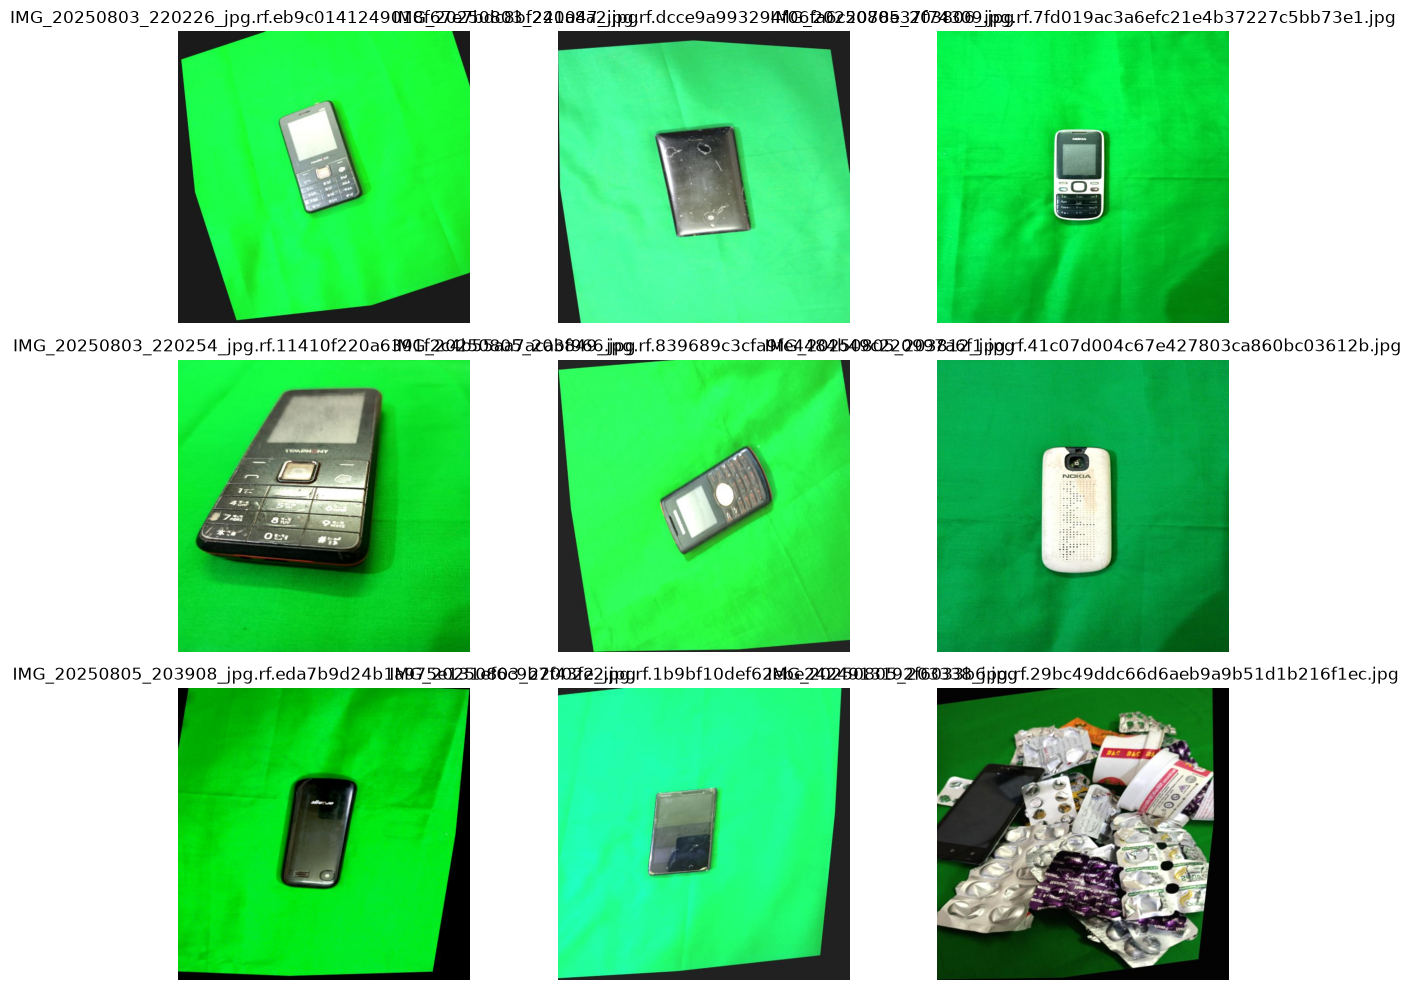

In [13]:
sample = random.sample(
    mobile_images,
    min(9, len(mobile_images))
)

plt.figure(figsize=(12, 10))

for i, image_path in enumerate(sample):

    img = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(image_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
import random
from PIL import Image
import matplotlib.pyplot as plt

pcb_images = []

for split in ["train", "valid", "test"]:

    label_folder = dataset_path / split / "labels"
    image_folder = dataset_path / split / "images"

    for label_file in label_folder.glob("*.txt"):

        contains_pcb = False

        with open(label_file, "r") as f:

            for line in f:

                if int(line.split()[0]) == 9:
                    contains_pcb = True
                    break

        if contains_pcb:

            for ext in [".jpg", ".jpeg", ".png"]:

                image_path = image_folder / (label_file.stem + ext)

                if image_path.exists():
                    pcb_images.append(image_path)
                    break

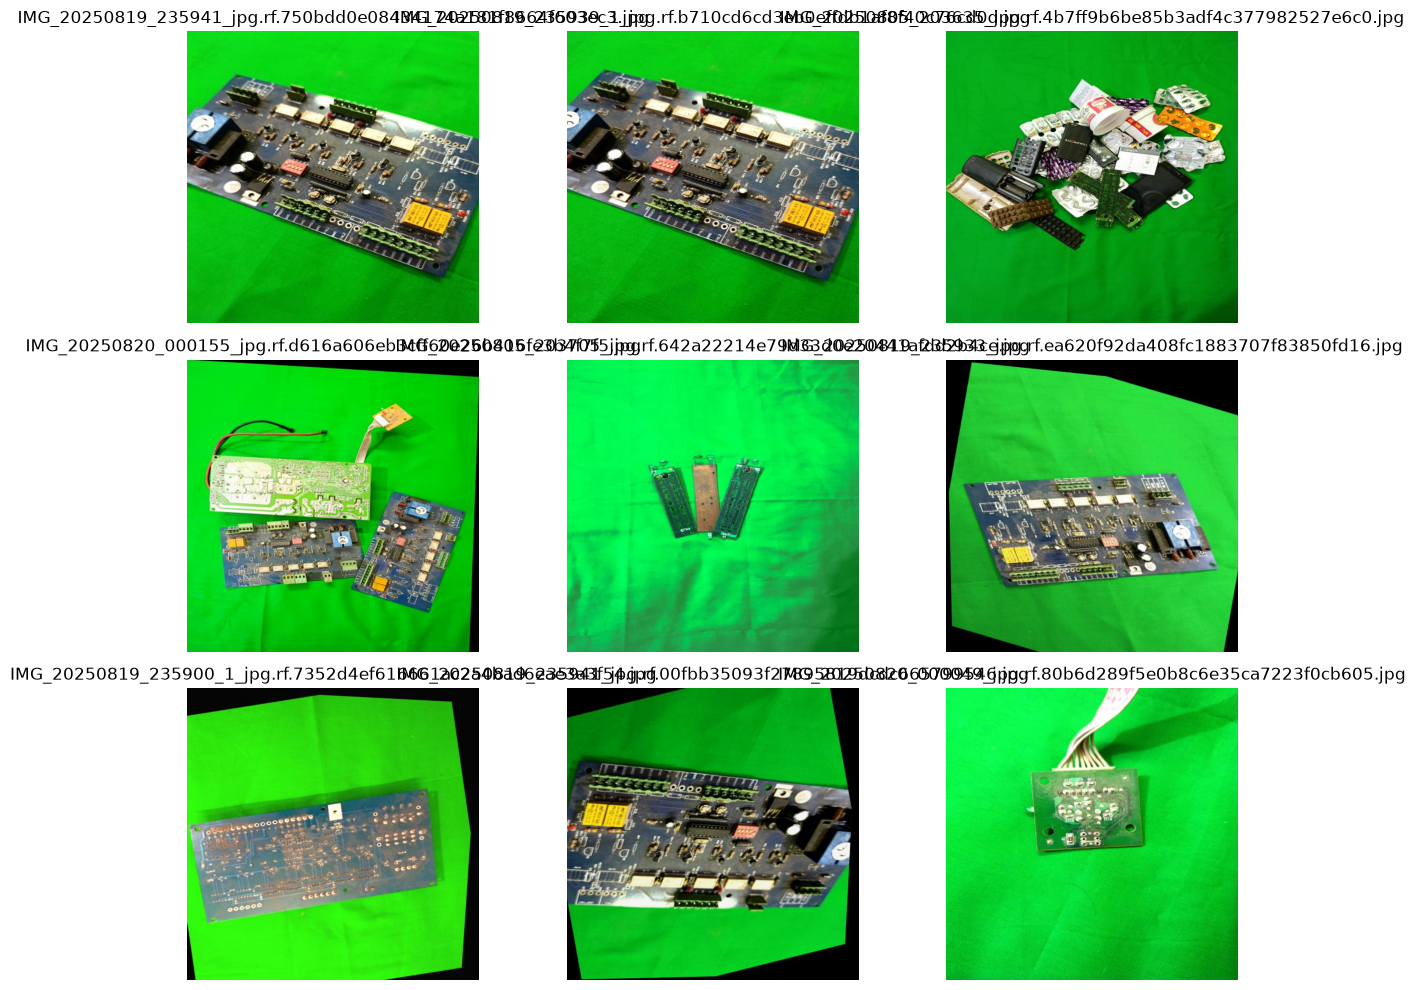

In [15]:
sample = random.sample(
    pcb_images,
    min(9, len(pcb_images))
)

plt.figure(figsize=(12, 10))

for i, image_path in enumerate(sample):

    img = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(image_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Verify every label has its exact matching image

In [3]:
for split in ["train", "valid", "test"]:

    image_folder = dataset_path / split / "images"
    label_folder = dataset_path / split / "labels"

    image_stems = {
        file.stem
        for file in image_folder.iterdir()
        if file.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp"]
    }

    label_stems = {
        file.stem
        for file in label_folder.glob("*.txt")
    }

    labels_without_images = label_stems - image_stems
    images_without_labels = image_stems - label_stems

    print(f"\n{split}")

    print(
        "Labels without matching images:",
        len(labels_without_images)
    )

    print(
        "Images without matching labels:",
        len(images_without_labels)
    )


train
Labels without matching images: 0
Images without matching labels: 0

valid
Labels without matching images: 0
Images without matching labels: 0

test
Labels without matching images: 0
Images without matching labels: 0


In [18]:
def find_image(image_folder, stem):
    for ext in [".jpg", ".jpeg", ".png", ".webp"]:
        path = image_folder / f"{stem}{ext}"
        if path.exists():
            return path
    return None

Check what Roboflow did to the dataset

In [4]:
readme_path = dataset_path / "README.roboflow.txt"

print(
    readme_path.read_text(
        encoding="utf-8",
        errors="ignore"
    )
)


E-Waste  - v5 2025-09-02 2:19pm

This dataset was exported via roboflow.com on September 5, 2025 at 1:15 PM GMT

Roboflow is an end-to-end computer vision platform that helps you
* collaborate with your team on computer vision projects
* collect & organize images
* understand and search unstructured image data
* annotate, and create datasets
* export, train, and deploy computer vision models
* use active learning to improve your dataset over time

For state of the art Computer Vision training notebooks you can use with this dataset,
visit https://github.com/roboflow/notebooks

To find over 100k other datasets and pre-trained models, visit https://universe.roboflow.com

The dataset includes 2157 images.
E-Waste are annotated in YOLOv9 format.

The following pre-processing was applied to each image:
* Auto-orientation of pixel data (with EXIF-orientation stripping)
* Resize to 640x640 (Stretch)
* Auto-contrast via contrast stretching

The following augmentation was applied to create 3 v

Draw YOLO bounding boxes

In [16]:
class_names = [
    'Battery_Waste',
    'Glass_Waste',
    'Keyboard',
    'Light_Bulb',
    'Medical_Waste',
    'Metal_Waste',
    'Mobile',
    'Mouse',
    'Organic_Waste',
    'PCB',
    'Paper_Waste',
    'Plastic_Waste'
]

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from PIL import Image
import numpy as np
import random

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
from PIL import Image
import random


def show_target_annotations(split, target_class_id, number=8):

    label_folder = dataset_path / split / "labels"
    image_folder = dataset_path / split / "images"

    matching_files = []

    for label_file in label_folder.glob("*.txt"):

        with open(label_file, "r") as f:

            lines = f.readlines()

        if any(
            line.strip()
            and int(line.split()[0]) == target_class_id
            for line in lines
        ):
            matching_files.append(label_file)

    samples = random.sample(
        matching_files,
        min(number, len(matching_files))
    )

    for label_file in samples:

        image_path = find_image(
            image_folder,
            label_file.stem
        )

        if image_path is None:
            continue

        img = Image.open(image_path)

        img_width, img_height = img.size

        fig, ax = plt.subplots()

        ax.imshow(img)

        with open(label_file, "r") as f:

            for line in f:

                parts = line.strip().split()

                if not parts:
                    continue

                class_id = int(parts[0])

                if class_id != target_class_id:
                    continue

                # -------------------------
                # FORMAT 1: Bounding box
                # -------------------------

                if len(parts) == 5:

                    x_center = float(parts[1])
                    y_center = float(parts[2])
                    width = float(parts[3])
                    height = float(parts[4])

                    w = width * img_width
                    h = height * img_height

                    x = x_center * img_width - w / 2
                    y = y_center * img_height - h / 2

                    rect = Rectangle(
                        (x, y),
                        w,
                        h,
                        fill=False,
                        linewidth=2
                    )

                    ax.add_patch(rect)

                # -------------------------
                # FORMAT 2: Polygon
                # -------------------------

                else:

                    coords = list(
                        map(float, parts[1:])
                    )

                    points = []

                    for i in range(0, len(coords), 2):

                        x = coords[i] * img_width
                        y = coords[i + 1] * img_height

                        points.append([x, y])

                    polygon = Polygon(
                        points,
                        fill=False,
                        linewidth=2
                    )

                    ax.add_patch(polygon)

        ax.set_title(
            f"{class_names[target_class_id]} | {image_path.name}"
        )

        ax.axis("off")

        plt.show()

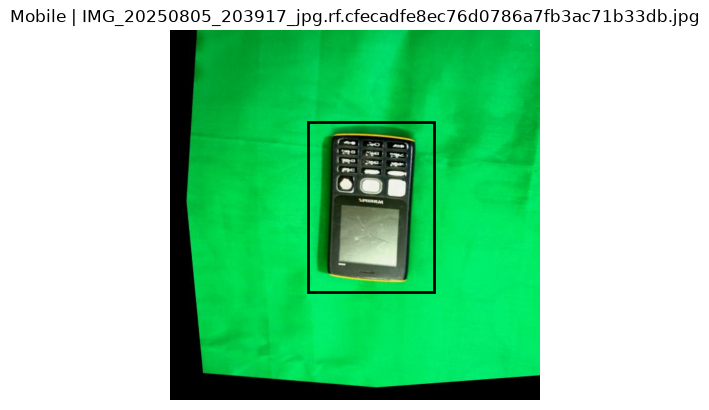

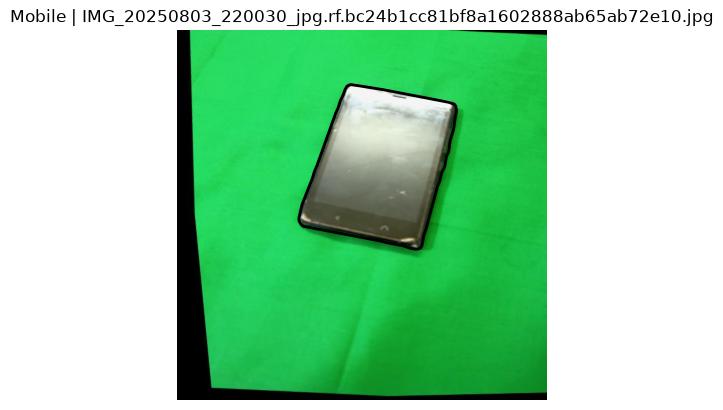

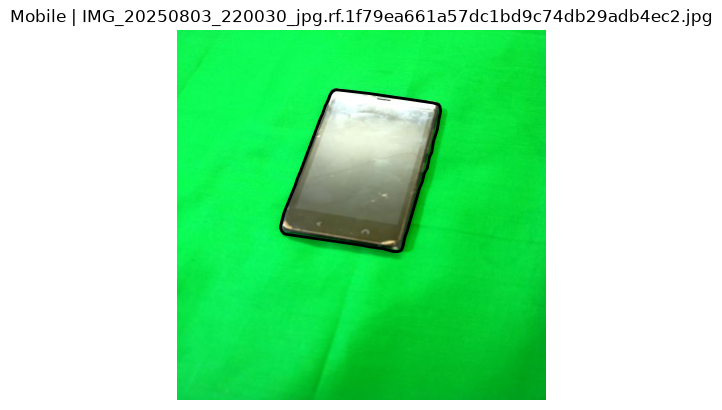

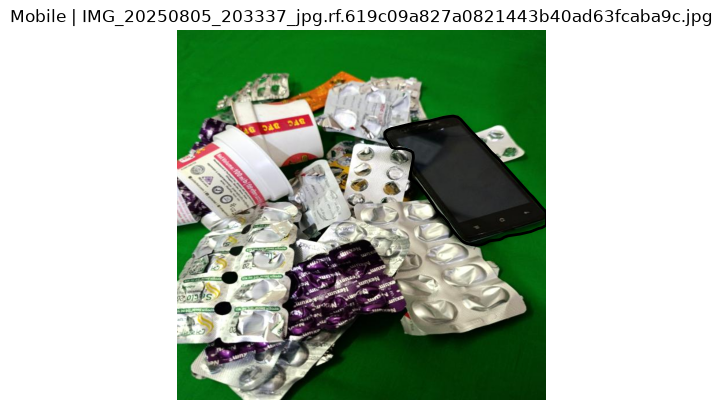

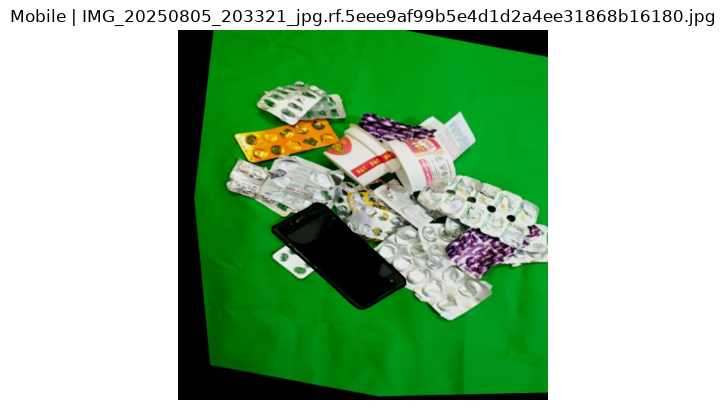

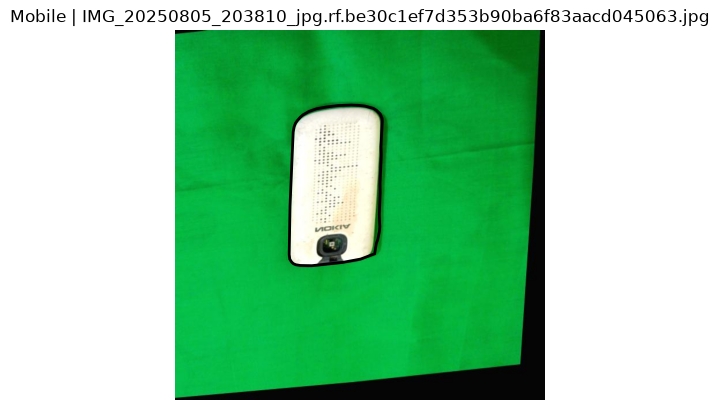

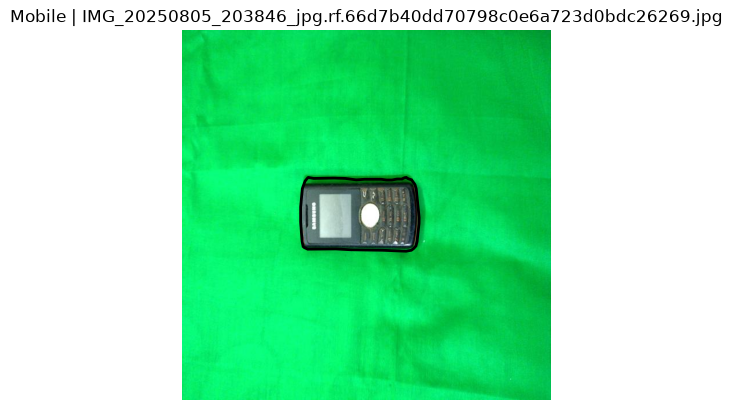

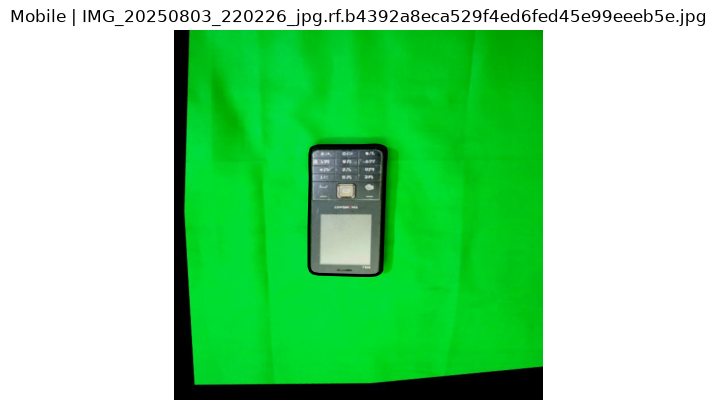

In [19]:
show_target_annotations("train", 6)

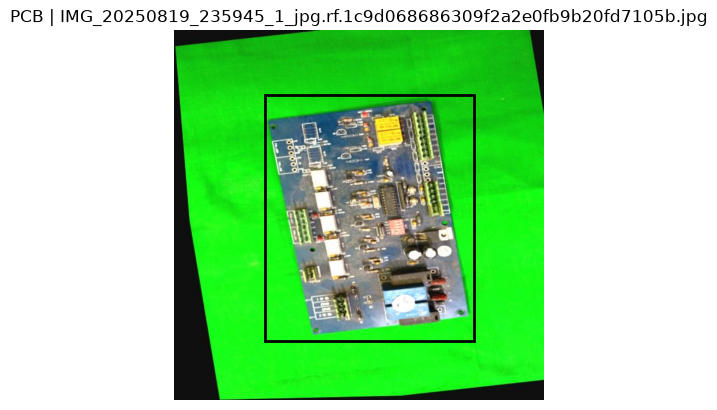

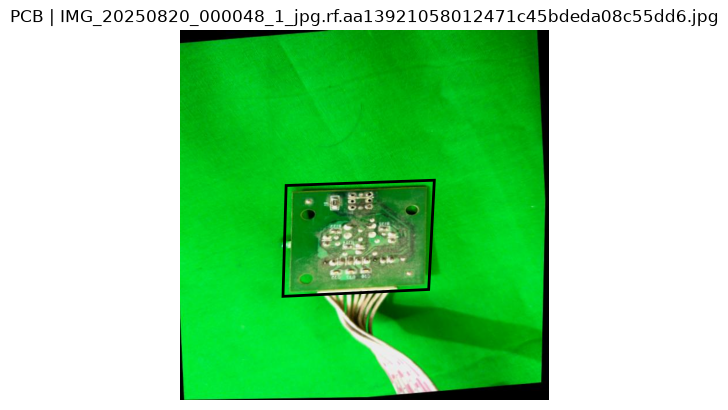

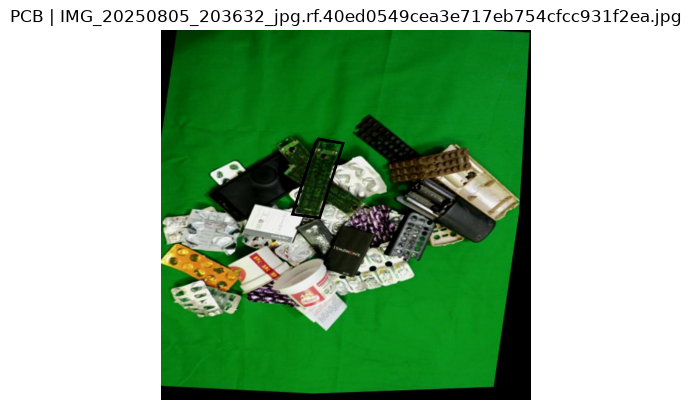

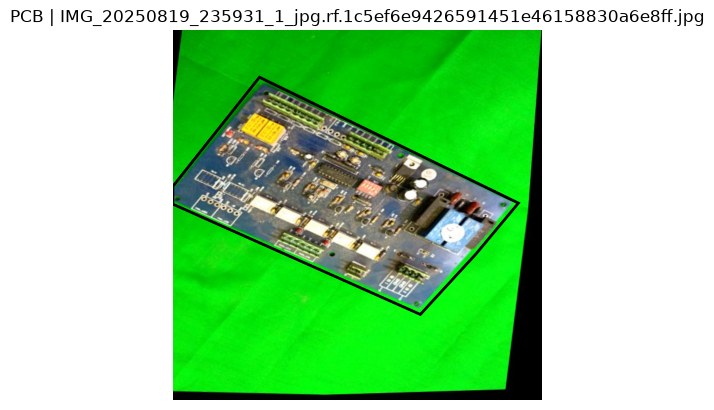

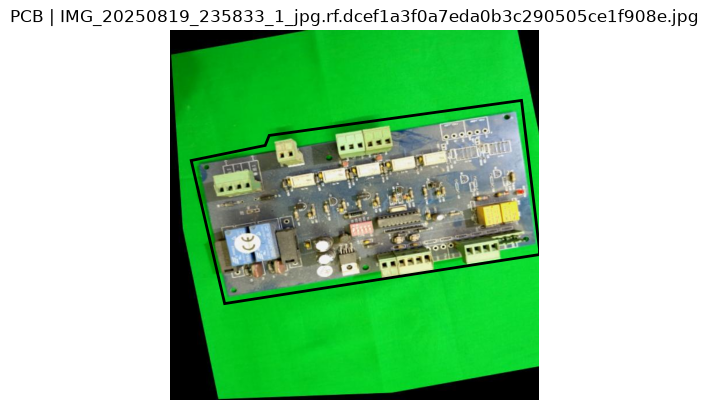

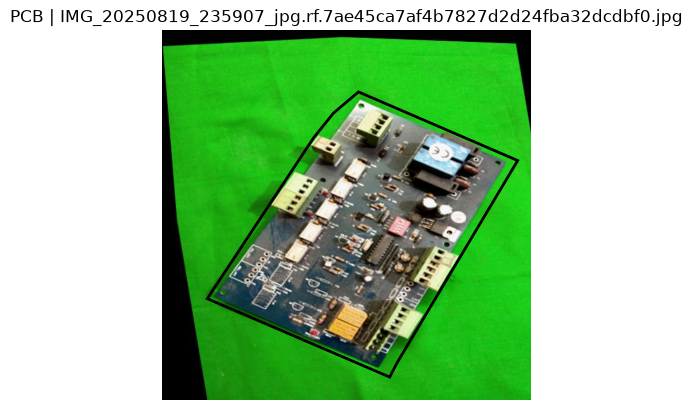

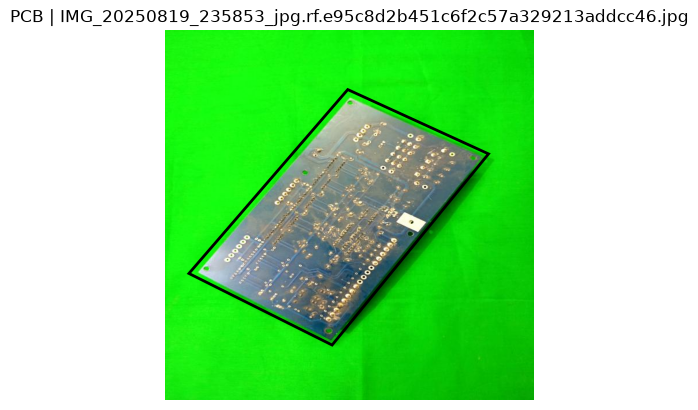

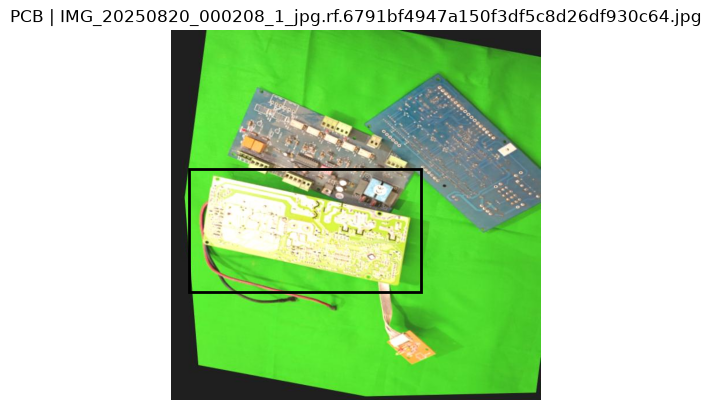

In [20]:
show_target_annotations("train", 9)

In [24]:
from collections import Counter

length_counts = Counter()

for split in ["train", "valid", "test"]:

    label_folder = dataset_path / split / "labels"

    for label_file in label_folder.glob("*.txt"):

        with open(label_file, "r") as f:

            for line in f:

                parts = line.strip().split()

                if parts and int(parts[0]) in [6, 9]:
                    length_counts[len(parts)] += 1

print(length_counts)

Counter({5: 127, 11: 65, 13: 38, 15: 32, 17: 19, 19: 19, 67: 6, 75: 6, 87: 4, 59: 4, 73: 3, 63: 3, 57: 3, 121: 3, 69: 3, 129: 3, 61: 3, 79: 3, 25: 3, 71: 3, 27: 2, 29: 1, 21: 1, 47: 1, 105: 1})


Check dimensions

In [21]:
target_image_paths = []

for split in ["train", "valid", "test"]:

    label_folder = dataset_path / split / "labels"
    image_folder = dataset_path / split / "images"

    for label_file in label_folder.glob("*.txt"):

        target_found = False

        with open(label_file, "r") as f:

            for line in f:

                class_id = int(line.split()[0])

                if class_id in [6, 9]:
                    target_found = True
                    break

        if target_found:

            image_path = find_image(
                image_folder,
                label_file.stem
            )

            if image_path:
                target_image_paths.append(image_path)

In [22]:
from collections import Counter

dimensions = []

for image_path in target_image_paths:

    with Image.open(image_path) as img:
        dimensions.append(img.size)

print("Number checked:", len(dimensions))

print("\nMost common dimensions:")
print(Counter(dimensions).most_common(10))

Number checked: 356

Most common dimensions:
[((640, 640), 356)]


In [23]:
widths = [w for w, h in dimensions]
heights = [h for w, h in dimensions]

print("Min width:", min(widths))
print("Max width:", max(widths))

print("Min height:", min(heights))
print("Max height:", max(heights))

Min width: 640
Max width: 640
Min height: 640
Max height: 640


Check corrupt images

In [24]:
corrupt_images = []

for image_path in target_image_paths:

    try:

        with Image.open(image_path) as img:
            img.verify()

    except Exception as e:

        corrupt_images.append(
            (image_path, str(e))
        )

print("Corrupt target images:", len(corrupt_images))

Corrupt target images: 0


Detect repeated original captures

In [38]:
import re
from collections import Counter, defaultdict
from pathlib import Path


def get_capture_group(filename):
    stem = Path(filename).stem

    # remove Roboflow hash
    base = stem.split(".rf.")[0]

    # remove exported extension marker
    base = re.sub(
        r"_(jpg|jpeg|png|webp)$",
        "",
        base,
        flags=re.IGNORECASE
    )

    return base


capture_groups = defaultdict(list)

for image_path in target_image_paths:

    group_id = get_capture_group(
        image_path.name
    )

    capture_groups[group_id].append(
        image_path.name
    )


repeated_groups = {
    group: files
    for group, files in capture_groups.items()
    if len(files) > 1
}


print(
    "Repeated capture groups:",
    len(repeated_groups)
)

for group, files in list(
    repeated_groups.items()
)[:10]:

    print("\n", group)

    for file in files:
        print("   ", file)

Repeated capture groups: 81

 IMG_20250803_220022
    IMG_20250803_220022_jpg.rf.1b9bf10def62ebe2424913192f6033b6.jpg
    IMG_20250803_220022_jpg.rf.2cd6a4959481bac2347cd2b2f4dc6d61.jpg
    IMG_20250803_220022_jpg.rf.dc0fdee22f504920709e6321bf117c22.jpg

 IMG_20250803_220030
    IMG_20250803_220030_jpg.rf.1f79ea661a57dc1bd9c74db29adb4ec2.jpg
    IMG_20250803_220030_jpg.rf.760f092cef34c6d36f6e2aed8301671b.jpg
    IMG_20250803_220030_jpg.rf.bc24b1cc81bf8a1602888ab65ab72e10.jpg

 IMG_20250803_220046
    IMG_20250803_220046_jpg.rf.3a0decfaa0e347e8daf2186f2dca2af1.jpg
    IMG_20250803_220046_jpg.rf.593a44abf20cee25f06845f455285742.jpg
    IMG_20250803_220046_jpg.rf.e75fd5549c943e12ae1d5c9f747e2c80.jpg

 IMG_20250803_220047
    IMG_20250803_220047_jpg.rf.13ad331e1f469809c4b1ba6f0748d0cf.jpg
    IMG_20250803_220047_jpg.rf.dcce9a993294f06fa6c2078e37f74309.jpg
    IMG_20250803_220047_jpg.rf.f69036399cb844d4fa35545cbe8bf18c.jpg

 IMG_20250803_220053
    IMG_20250803_220053_jpg.rf.143f84f401009a4

Calculate object size CORRECTLY

In [27]:
def polygon_area(points):

    area = 0

    n = len(points)

    for i in range(n):

        x1, y1 = points[i]
        x2, y2 = points[(i + 1) % n]

        area += x1 * y2 - x2 * y1

    return abs(area) / 2

In [28]:
object_ratios = {
    "mobile_phone": [],
    "pcb": []
}

annotation_types = {
    "bbox": 0,
    "polygon": 0
}


for split in ["train", "valid", "test"]:

    label_folder = dataset_path / split / "labels"

    for label_file in label_folder.glob("*.txt"):

        with open(label_file, "r") as f:

            for line in f:

                parts = line.strip().split()

                if not parts:
                    continue

                class_id = int(parts[0])

                if class_id not in [6, 9]:
                    continue

                class_name = (
                    "mobile_phone"
                    if class_id == 6
                    else "pcb"
                )

                # BOUNDING BOX
                if len(parts) == 5:

                    width = float(parts[3])
                    height = float(parts[4])

                    area_ratio = width * height

                    annotation_types["bbox"] += 1

                # POLYGON
                else:

                    coords = list(
                        map(float, parts[1:])
                    )

                    points = [
                        (
                            coords[i],
                            coords[i + 1]
                        )
                        for i in range(
                            0,
                            len(coords),
                            2
                        )
                    ]

                    area_ratio = polygon_area(points)

                    annotation_types["polygon"] += 1


                object_ratios[class_name].append(
                    area_ratio
                )

In [29]:
print("Annotation types:")
print(annotation_types)


for class_name, ratios in object_ratios.items():

    print(f"\n{class_name}")

    print("Objects:", len(ratios))

    print(
        "Average area ratio:",
        sum(ratios) / len(ratios)
    )

    print(
        "Minimum:",
        min(ratios)
    )

    print(
        "Maximum:",
        max(ratios)
    )

Annotation types:
{'bbox': 127, 'polygon': 229}

mobile_phone
Objects: 151
Average area ratio: 0.09960853154261357
Minimum: 0.024987792968750002
Maximum: 0.31834421517934364

pcb
Objects: 205
Average area ratio: 0.2553946718288235
Minimum: 0.01371581188780005
Maximum: 0.6681864420572916


Check exact duplicates

In [30]:
import hashlib
from collections import defaultdict

hash_to_files = defaultdict(list)

for split in ["train", "valid", "test"]:

    image_folder = dataset_path / split / "images"

    for image_path in image_folder.iterdir():

        if image_path.suffix.lower() not in [".jpg", ".jpeg", ".png", ".webp"]:
            continue

        with open(image_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        hash_to_files[file_hash].append(
            (split, image_path.name)
        )

In [31]:
duplicate_groups = [
    files
    for files in hash_to_files.values()
    if len(files) > 1
]

print("Exact duplicate groups:", len(duplicate_groups))

for group in duplicate_groups[:10]:
    print(group)

Exact duplicate groups: 0


EDA conclusions

Manual observations

Mobile:
- 151 annotated images.
- Target object is generally clearly visible.
- Some photographs contain additional physical electronic items even though only one object may be annotated.
- Background is heavily dominated by the same green cloth.
- Lighting variation is limited.
- Similar objects/captures appear in several variants.
- Dataset should only be used as a supplementary mobile_phone source.

PCB:
- 205 annotated images.
- PCB is generally clearly visible.
- Dataset contains both bounding-box and polygon annotations.
- Several images appear to be variants of the same original capture/object.
- Green background and lighting are highly consistent.
- Some images contain surrounding/cluttered electronics.
- Dataset should only be used as a supplementary PCB source.

Annotation quality:
- Target annotations use mixed YOLO representations.
- Some samples use bounding boxes while others use segmentation polygons.
- A unified parser is therefore required.
- Image-label matching should be performed using the complete filename stem.

Manifest

In [39]:
import pandas as pd


target_mapping = {
    6: "mobile_phone",
    9: "pcb"
}

rows = []


for split in ["train", "valid", "test"]:

    label_folder = dataset_path / split / "labels"
    image_folder = dataset_path / split / "images"


    for label_file in label_folder.glob("*.txt"):

        image_path = find_image(
            image_folder,
            label_file.stem
        )

        if image_path is None:
            continue


        with Image.open(image_path) as img:

            image_width, image_height = img.size


        with open(label_file, "r") as f:

            for line in f:

                parts = line.strip().split()

                if not parts:
                    continue

                class_id = int(parts[0])

                if class_id not in target_mapping:
                    continue


                # ------------------
                # Bounding box
                # ------------------

                if len(parts) == 5:

                    annotation_type = "bbox"

                    xc = float(parts[1])
                    yc = float(parts[2])

                    w = float(parts[3])
                    h = float(parts[4])

                    xmin = xc - w / 2
                    ymin = yc - h / 2

                    xmax = xc + w / 2
                    ymax = yc + h / 2

                    object_area_ratio = w * h


                # ------------------
                # Polygon
                # ------------------

                else:

                    annotation_type = "polygon"

                    coords = list(
                        map(float, parts[1:])
                    )

                    points = [
                        (
                            coords[i],
                            coords[i + 1]
                        )
                        for i in range(
                            0,
                            len(coords),
                            2
                        )
                    ]

                    xs = [p[0] for p in points]
                    ys = [p[1] for p in points]

                    xmin = min(xs)
                    ymin = min(ys)

                    xmax = max(xs)
                    ymax = max(ys)

                    object_area_ratio = polygon_area(
                        points
                    )


                # keep within valid range

                xmin = max(0, xmin)
                ymin = max(0, ymin)

                xmax = min(1, xmax)
                ymax = min(1, ymax)


                capture_group_id = get_capture_group(
                    image_path.name
                )


                rows.append({

                    "file_name":
                        image_path.name,

                    "source_dataset":
                        "Custom Bangladeshi E-Waste Dataset",

                    "original_split":
                        split,

                    "original_class_id":
                        class_id,

                    "original_label":
                        class_names[class_id],

                    "esafe_label":
                        target_mapping[class_id],

                    "width":
                        image_width,

                    "height":
                        image_height,

                    "annotation_type":
                        annotation_type,

                    "crop_xmin":
                        xmin,

                    "crop_ymin":
                        ymin,

                    "crop_xmax":
                        xmax,

                    "crop_ymax":
                        ymax,

                    "object_area_ratio":
                        object_area_ratio,

                    "capture_group_id":
                        capture_group_id
                })

In [40]:
bangladesh_df = pd.DataFrame(rows)

print(bangladesh_df.shape)

print(
    bangladesh_df["esafe_label"]
    .value_counts()
)

print(
    bangladesh_df["annotation_type"]
    .value_counts()
)

bangladesh_df.head()

(356, 15)
esafe_label
pcb             205
mobile_phone    151
Name: count, dtype: int64
annotation_type
polygon    229
bbox       127
Name: count, dtype: int64


,file_name,source_dataset,original_split,original_class_id,original_label,esafe_label,width,height,annotation_type,crop_xmin,crop_ymin,crop_xmax,crop_ymax,object_area_ratio,capture_group_id
0,IMG_20250803_220022_jpg.rf.1b9bf10def62ebe2424...,Custom Bangladeshi E-Waste Dataset,train,6,Mobile,mobile_phone,640,640,polygon,0.308584,0.343344,0.548721,0.647311,0.061812,IMG_20250803_220022
1,IMG_20250803_220022_jpg.rf.2cd6a4959481bac2347...,Custom Bangladeshi E-Waste Dataset,train,6,Mobile,mobile_phone,640,640,polygon,0.357770,0.345782,0.626478,0.664327,0.062386,IMG_20250803_220022
2,IMG_20250803_220022_jpg.rf.dc0fdee22f504920709...,Custom Bangladeshi E-Waste Dataset,train,6,Mobile,mobile_phone,640,640,polygon,0.368490,0.378431,0.594727,0.671324,0.062195,IMG_20250803_220022
3,IMG_20250803_220030_jpg.rf.1f79ea661a57dc1bd9c...,Custom Bangladeshi E-Waste Dataset,train,6,Mobile,mobile_phone,640,640,polygon,0.280599,0.160049,0.713867,0.597794,0.132011,IMG_20250803_220030
4,IMG_20250803_220030_jpg.rf.760f092cef34c6d36f6...,Custom Bangladeshi E-Waste Dataset,train,6,Mobile,mobile_phone,640,640,polygon,0.269727,0.415517,0.713011,0.862029,0.132083,IMG_20250803_220030


In [41]:
bangladesh_df.insert(
    0,
    "file_id",
    [
        f"BE{i:05d}"
        for i in range(
            1,
            len(bangladesh_df) + 1
        )
    ]
)

In [42]:
output_path = (
    "../../data/metadata/"
    "bangladesh_ewaste_manifest.csv"
)

bangladesh_df.to_csv(
    output_path,
    index=False
)

In [43]:
pd.read_csv(output_path).head()

,file_id,file_name,source_dataset,original_split,original_class_id,original_label,esafe_label,width,height,annotation_type,crop_xmin,crop_ymin,crop_xmax,crop_ymax,object_area_ratio,capture_group_id
0,BE00001,IMG_20250803_220022_jpg.rf.1b9bf10def62ebe2424...,Custom Bangladeshi E-Waste Dataset,train,6,Mobile,mobile_phone,640,640,polygon,0.308584,0.343344,0.548721,0.647311,0.061812,IMG_20250803_220022
1,BE00002,IMG_20250803_220022_jpg.rf.2cd6a4959481bac2347...,Custom Bangladeshi E-Waste Dataset,train,6,Mobile,mobile_phone,640,640,polygon,0.357770,0.345782,0.626478,0.664327,0.062386,IMG_20250803_220022
2,BE00003,IMG_20250803_220022_jpg.rf.dc0fdee22f504920709...,Custom Bangladeshi E-Waste Dataset,train,6,Mobile,mobile_phone,640,640,polygon,0.368490,0.378431,0.594727,0.671324,0.062195,IMG_20250803_220022
3,BE00004,IMG_20250803_220030_jpg.rf.1f79ea661a57dc1bd9c...,Custom Bangladeshi E-Waste Dataset,train,6,Mobile,mobile_phone,640,640,polygon,0.280599,0.160049,0.713867,0.597794,0.132011,IMG_20250803_220030
4,BE00005,IMG_20250803_220030_jpg.rf.760f092cef34c6d36f6...,Custom Bangladeshi E-Waste Dataset,train,6,Mobile,mobile_phone,640,640,polygon,0.269727,0.415517,0.713011,0.862029,0.132083,IMG_20250803_220030


In [44]:
group_splits = (
    bangladesh_df
    .groupby("capture_group_id")["original_split"]
    .agg(lambda x: sorted(set(x)))
)

cross_split_groups = group_splits[
    group_splits.apply(len) > 1
]

print(
    "Capture groups appearing in multiple splits:",
    len(cross_split_groups)
)

print(cross_split_groups.head(20))

Capture groups appearing in multiple splits: 0
Series([], Name: original_split, dtype: object)


Dataset preprocessing:
- EXIF auto-orientation
- resized to 640×640 using stretch
- auto-contrast

Provided augmentation:
- horizontal flip
- vertical flip
- rotation ±15°
- shear ±15°
- brightness ±15%
- 3 versions created per source image